In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


In [ ]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 236MB/s]



In [ ]:
!unzip /content/fer2013.zip -d/content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/sad/Training_65242339.jpg  
  inflating: /content/train/sad/Training_65267116.jpg  
  inflating: /content/train/sad/Training_65275626.jpg  
  inflating: /content/train/sad/Training_6529266.jpg  
  inflating: /content/train/sad/Training_65329617.jpg  
  inflating: /content/train/sad/Training_65338712.jpg  
  inflating: /content/train/sad/Training_65338797.jpg  
  inflating: /content/train/sad/Training_65387162.jpg  
  inflating: /content/train/sad/Training_65404494.jpg  
  inflating: /content/train/sad/Training_65426218.jpg  
  inflating: /content/train/sad/Training_65430136.jpg  
  inflating: /content/train/sad/Training_65437377.jpg  
  inflating: /content/train/sad/Training_6545735.jpg  
  inflating: /content/train/sad/Training_65463385.jpg  
  inflating: /content/train/sad/Training_65473985.jpg  
  inflating: /content/train/sad/Training_65502829.jpg  
  inflating: /content/train/sad/Training_65505359.jpg  

In [ ]:
!pip install tensorflow panda numpy keras matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for panda: filename=panda-0.3.1-py3-none-any.whl size=7239 sha256=b59cb85e8c52a0d9292747b4f1518de3899b65cd166bed96c5fd64e96f1c6563
  Stored in directory: /root/.cache/pip/wheels/98/41/5b/6ca54e0b6a35e1b7248c12f56fcb753dfb7717fefaa0fb45f5
Successfully built panda


In [ ]:
def plot_image_from_directory(imgPath, num):
    image = []
    for root, dirs, files in os.walk(imgPath):
        for file in files:
            if file.lower().endswith(('.png','jpg','jpeg')):
                image.append(os.path.join(root,file))
    if len(image)<num :
        print(f"found only {len(image)} in directory{imgPath}")
        num = len(image)
    selected_images = random.sample(image,num)
    fig,axes = plt.subplots(3,3,figsize=(8,8))
    axes = axes.flatten()
    for i , img_file in enumerate(selected_images):
        img_path = os.path.join(imgPath,img_file)
        with Image.open(img_path) as image:
            axes[i].imshow(image,cmap='gray')
            axes[i].axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    Activation, BatchNormalization, Flatten,GlobalAveragePooling2D
)
from tensorflow.keras.regularizers import l2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array , load_img
import seaborn as sns
from keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report , accuracy_score

from PIL import Image
import os
import random
import cv2


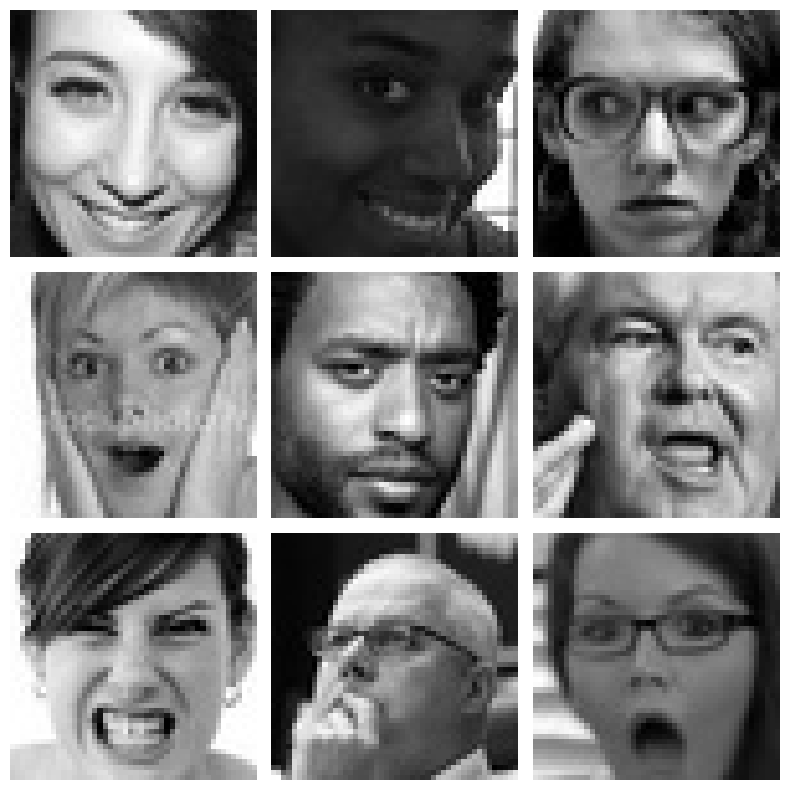

In [ ]:

 plot_image_from_directory("/content/train", 9)

In [ ]:
train_dir = '/content/train'
test_dir = '/content/test'

batch_size = 64

train_datagen = ImageDataGenerator(
    rescale=1/255.,
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1/255.)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
classes = np.array(train_generator.classes)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"class weights : {class_weights}")

class weights : [1.02664044 9.40155546 1.00095877 0.56845857 0.82606819 0.84915705
 1.29331607]


In [ ]:
from tensorflow.keras.applications import ResNet50V2
base_model = ResNet50V2(
    input_shape=(224,224,3),
    include_top = False,
    weights = 'imagenet'
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:

model = Sequential()

model.add(base_model)

model.add(GlobalAveragePooling2D())

model.add(BatchNormalization())
model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,704,839 (90.43 MB)

 Trainable params: 23,655,175 (90.24 MB)

 Non-trainable params: 49,664 (194.00 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau,TensorBoard,CSVLogger

In [ ]:
# File path for the model checkpoint
cnn_path = '/content/drive/MyDrive/transfer_learning'
os.makedirs(cnn_path, exist_ok=True)
name = 'ResNet50_Transfer_Learning.keras'
chk_path = os.path.join(cnn_path, name)

import os, math


checkpoint = ModelCheckpoint(
    filepath=chk_path,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

csv_logger = CSVLogger(os.path.join(cnn_path,'training.log'))

callbacks = [checkpoint, earlystop, reduce_lr, csv_logger]

train_steps = math.ceil(train_generator.samples / train_generator.batch_size)
val_steps = math.ceil(val_generator.samples / val_generator.batch_size)


In [ ]:
train_history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=30,
    validation_data=val_generator,
    validation_steps=val_steps,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2513 - loss: 2.1536
Epoch 1: val_loss improved from None to 1.43802, saving model to /content/drive/MyDrive/transfer_learning/ResNet50_Transfer_Learning.keras

Epoch 1: finished saving model to /content/drive/MyDrive/transfer_learning/ResNet50_Transfer_Learning.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - accuracy: 0.3180 - loss: 1.8752 - val_accuracy: 0.4623 - val_loss: 1.4380 - learning_rate: 1.0000e-04
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.4429 - loss: 1.4700
Epoch 2: val_loss improved from 1.43802 to 1.37380, saving model to /content/drive/MyDrive/transfer_learning/ResNet50_Transfer_Learning.keras

Epoch 2: finished saving model to /content/drive/MyDrive/transfer_learning/ResNet50_Transfer_Learning.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 459s 1s/step - accuracy: 0.4621 - loss: 1.4177 - val_accuracy: 0.4806 - val_loss: 1.3738 - learning_rate: 1.0000e-04
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plotAccuracyFromLog(log_path):
    df = pd.read_csv(log_path)

    acc = df['accuracy']
    val_acc = df['val_accuracy']
    loss = df['loss']
    val_loss = df['val_loss']

    epochs_range = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Accuracy plot
    axes[0].plot(epochs_range, acc, label='Training Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Validation Accuracy')
    axes[0].set_title('Training vs Validation Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss plot
    axes[1].plot(epochs_range, loss, label='Training Loss')
    axes[1].plot(epochs_range, val_loss, label='Validation Loss')
    axes[1].set_title('Training vs Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.show()

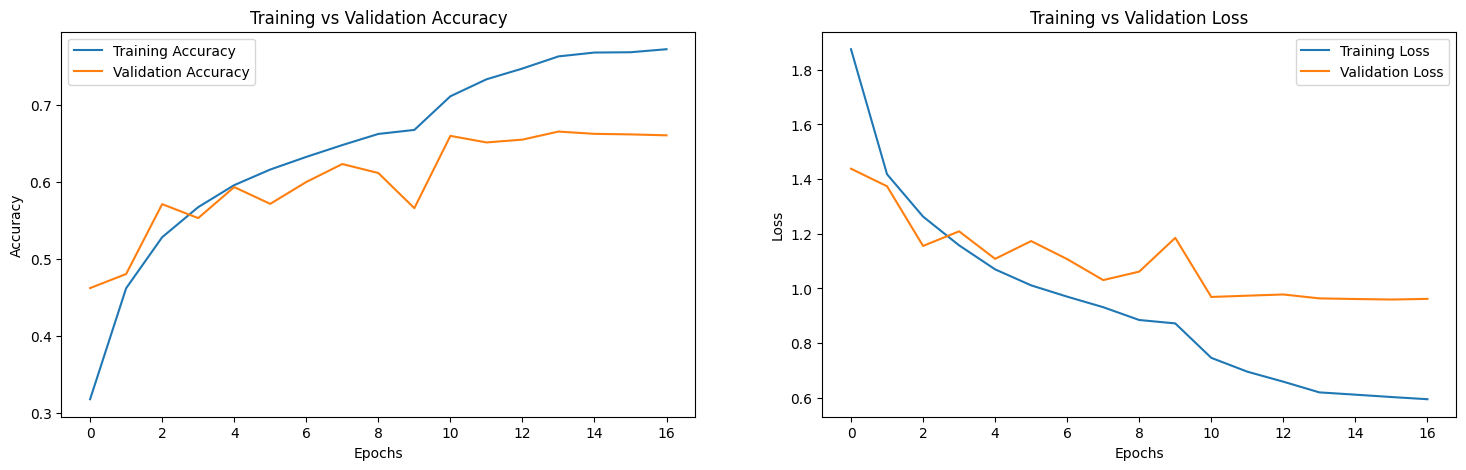

In [ ]:
plotAccuracyFromLog('/content/drive/MyDrive/transfer_learning/training.log')

In [ ]:
import os

path = '/content/drive/MyDrive/transfer_learning/ResNet50_Transfer_Learning.keras'
print(os.path.exists(path))

True


In [ ]:
model.input_shape

(None, 224, 224, 3)

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image



class_names = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprise']
def predict_emotion(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)
    pred_index = np.argmax(preds)
    emotion = class_names[pred_index]
    confidence = float(np.max(preds))
    return emotion, confidence

In [ ]:
img_path = '/content/Screenshot 2026-02-09 222433.png'
emotion, confidence = predict_emotion(img_path)
print(emotion, confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Angry 0.5245698094367981


In [ ]:
train_loss, train_accu = model.evaluate(train_generator)
test_loss, test_accu = model.evaluate(test_generator)

359/359 ━━━━━━━━━━━━━━━━━━━━ 353s 942ms/step - accuracy: 0.8019 - loss: 0.5539
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 210ms/step - accuracy: 0.6831 - loss: 0.9269


In [ ]:
print("Train Accuracy = {:.2f}% , Test Accuracy = {:.2f}%".format(train_accu*100, test_accu*100))

Train Accuracy = 80.19% , Test Accuracy = 68.31%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

true_classes = test_generator.classes

preds = model.predict(test_generator)
predicted_classes = np.argmax(preds, axis=1)

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)



113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 211ms/step


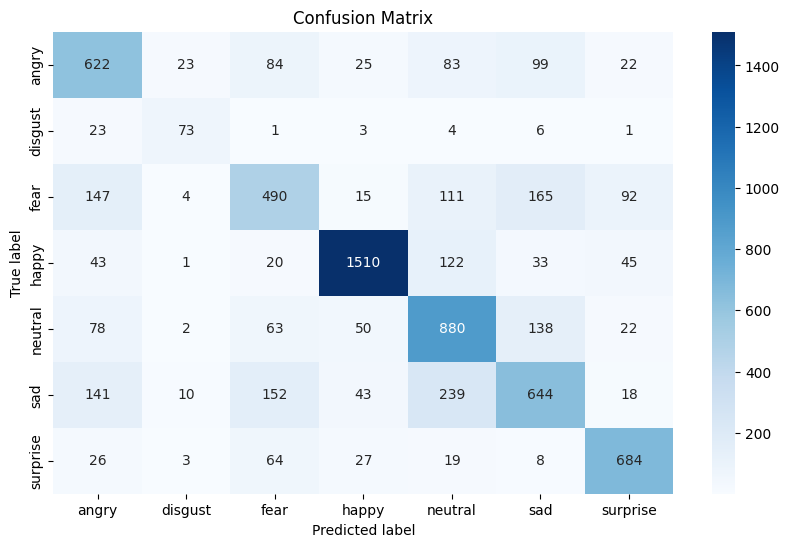

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/transfer_learning/ResNet50_Transfer_Learning.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip3 install gradio

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array,load_img
import gradio as gr
import tensorflow as tf
from PIL import Image
import cv2
from tensorflow.keras.preprocessing import image

In [ ]:
train_generator.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [ ]:
model = load_model('/content/drive/MyDrive/transfer_learning/ResNet50_Transfer_Learning.keras')
class_names = {'Angry':0,'Disgust':1,'Fear':2,'Happy':3,'Neutral':4,'Sad':5,'Surprise':6}
index_to_emotion = {v:k for k,v in class_names.items()}
def prepare_image(img_pil):
    img = img_pil.resize((224,224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    return img_array

def predict_emotion(image):
    processed_image = prepare_image(image)
    prediction = model.predict(processed_image)
    predicted_class = np.argmax(prediction,axis=1)
    predicted_emotion = index_to_emotion.get(predicted_class[0],"Unknown Emotion")
    return predicted_emotion

interface = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Emotion Recognition",
    description="Upload an image and get the predicted emotion."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc65a460f040ddbd69.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
